<a href="https://colab.research.google.com/github/harshchaturkar/Mini-Project-repo/blob/main/assignment28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("train.txt", sep=";", names=["text", "emotion"])

In [ ]:
df.head(10)

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [ ]:
df.shape

(16000, 2)

In [ ]:
df.isnull().sum()

,0
text,0
emotion,0


In [ ]:
print("Unique emotion lable")
print(df["emotion"].unique())

Unique emotion lable
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le =LabelEncoder()
df["emotion_encoded"] = le.fit_transform(df["emotion"])

In [ ]:
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nEmotion Label Mapping:")
print(label_mapping)



Emotion Label Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}


In [ ]:
print("\nDataFrame with Encoded Labels:")
print(df.head())



DataFrame with Encoded Labels:
                                                text  emotion  emotion_encoded
0                            i didnt feel humiliated  sadness                4
1  i can go from feeling so hopeless to so damned...  sadness                4
2   im grabbing a minute to post i feel greedy wrong    anger                0
3  i am ever feeling nostalgic about the fireplac...     love                3
4                               i am feeling grouchy    anger                0


In [ ]:
print("Before Lowercasing:")
print(df["text"].head())
df["text"] = df["text"].str.lower()
print("\nAfter Lowercasing:")
print(df["text"].head())

Before Lowercasing:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object

After Lowercasing:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


**Why lowercasing is important in NLP**
*   Makes text consistent.

*   Treats Happy and happy as the same word.
*   List itemReduces duplicate words.

*   Helps NLP models work better.


In [ ]:
import string

def remove_punctuation(text):
  return text.translate(str.maketrans("", "",string.punctuation))

print("Before Removing Punctuation:")
print(df["text"].head())

df["text"] = df["text"].apply(remove_punctuation)

print("\nAfter Removing Punctuation:")
print(df["text"].head())

Before Removing Punctuation:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object

After Removing Punctuation:
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


In [ ]:
print("Before removing number ")
print(df["text"].head())

df["text"] = df["text"].str.translate(str.maketrans("", "", "0123456789"))

print("\nAfter removing number ")
print(df["text"].head())

Before removing number 
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object

After removing number 
0                              i didnt feel humiliated
1    i can go from feeling so hopeless to so damned...
2     im grabbing a minute to post i feel greedy wrong
3    i am ever feeling nostalgic about the fireplac...
4                                 i am feeling grouchy
Name: text, dtype: object


In [ ]:
def keep_ascii(text):
    return ''.join(ch for ch in str(text) if ord(ch) < 128)

df["text_ascii"] = df["text"].apply(keep_ascii)

print(df[["text", "text_ascii"]].head())

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                          text_ascii  
0                            i didnt feel humiliated  
1  i can go from feeling so hopeless to so damned...  
2   im grabbing a minute to post i feel greedy wrong  
3  i am ever feeling nostalgic about the fireplac...  
4                               i am feeling grouchy  


In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    new_words = []

    for word in words:
        if word.lower() not in stop_words:
            new_words.append(word)

    return " ".join(new_words)

df["text_clean"] = df["text"].apply(remove_stopwords)
print(df[["text", "text_clean"]].head())

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   

                                          text_clean  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import string
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = text.lower()
    text = ''.join(ch for ch in text if ch not in string.punctuation)
    text = ''.join(ch for ch in text if not ch.isdigit())
    text = ''.join(ch for ch in text if ord(ch) < 128)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["cleaned_text"] = df["text"].apply(clean_text)
print(df[["text", "cleaned_text"]].head(10))

                                                text  \
0                            i didnt feel humiliated   
1  i can go from feeling so hopeless to so damned...   
2   im grabbing a minute to post i feel greedy wrong   
3  i am ever feeling nostalgic about the fireplac...   
4                               i am feeling grouchy   
5  ive been feeling a little burdened lately wasn...   
6  ive been taking or milligrams or times recomme...   
7  i feel as confused about life as a teenager or...   
8  i have been with petronas for years i feel tha...   
9                                i feel romantic too   

                                        cleaned_text  
0                              didnt feel humiliated  
1  go feeling hopeless damned hopeful around some...  
2          im grabbing minute post feel greedy wrong  
3  ever feeling nostalgic fireplace know still pr...  
4                                    feeling grouchy  
5      ive feeling little burdened lately wasnt sure 

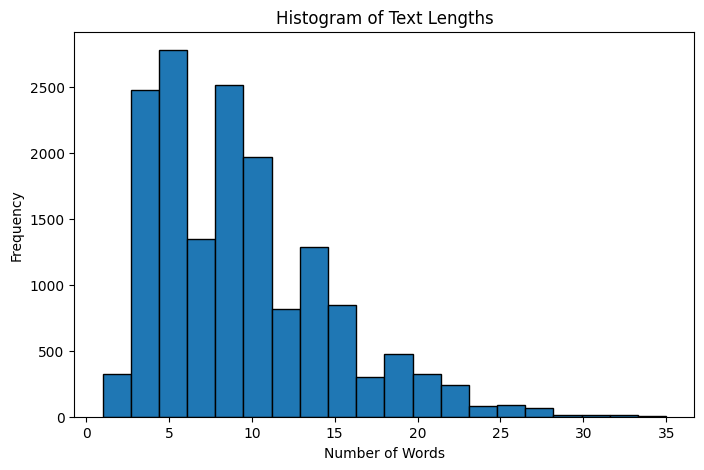

Average Text Length : 9.3530625
Minimum Text Length : 1
Maximum Text Length : 35


In [ ]:
import matplotlib.pyplot as plt

df["text_length"] = df["cleaned_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=20, edgecolor="black")
plt.title("Histogram of Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print("Average Text Length :", df["text_length"].mean())
print("Minimum Text Length :", df["text_length"].min())
print("Maximum Text Length :", df["text_length"].max())

**Observations**

Most cleaned texts contain 3–10 words.
The average text length is 9.35 words.
The minimum length is 1 word and the maximum is 35 words.
Cleaning removed unnecessary words and symbols, making the text suitable for NLP tasks.

In [ ]:
nltk.download("stopwords")
df = pd.read_csv("train.txt", sep=";", names=["text", "emotion"])

le = LabelEncoder()
df["emotion"] = le.fit_transform(df["emotion"])

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = ''.join(ch for ch in text if ch not in string.punctuation)
    text = ''.join(ch for ch in text if not ch.isdigit())
    text = ''.join(ch for ch in text if ord(ch) < 128)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["cleaned_text"] = df["text"].apply(clean_text)
df.to_csv("cleaned_emotions.csv", index=False)
print(df["emotion"].value_counts())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


emotion
2    5362
4    4666
0    2159
1    1937
3    1304
5     572
Name: count, dtype: int64
